<a href="https://colab.research.google.com/github/Arif0000/Pytorch/blob/main/Classification_NN_using_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt



In [22]:
train_dataset = datasets.FashionMNIST(root='/dataset', train=True, transform=transforms.ToTensor(),download=True)
test_dataset = datasets.FashionMNIST(root='dataset', train=False, transform=transforms.ToTensor(), download=True)

In [23]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: /dataset
    Split: Train
    StandardTransform
Transform: ToTensor()

In [24]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: dataset
    Split: Test
    StandardTransform
Transform: ToTensor()

In [25]:
batch_size=64
device='cuda' if torch.cuda.is_available() else 'cpu'

In [26]:
train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [27]:
len(list(train_loader))

938

In [28]:
len(list(test_loader))

157

In [29]:
from torch.nn.modules.activation import ReLU
class NeuralNetwork(nn.Module):
  def __init__(self, in_dim, n_hidden_1, n_hidden_2, out_dim):
    super().__init__()
    self.layer1=nn.Sequential(
        nn.Linear(in_dim, n_hidden_1),
        nn.ReLU(True)
    )
    self.layer2=nn.Sequential(
        nn.Linear(n_hidden_1, n_hidden_2),
        nn.ReLU(True)
    )
    self.layer3=nn.Sequential(
        nn.Linear(n_hidden_2, out_dim),
        nn.ReLU(True)
    )
  def forward(self, x):
      x = self.layer1(x)
      x = self.layer2(x)
      x = self.layer3(x)
      return x

In [30]:
in_dim = 28 * 28
n_hidden_1=300
n_hidden_2=100
out_dim=10

In [31]:
model=NeuralNetwork(in_dim,n_hidden_1,n_hidden_2,out_dim)

In [32]:
model

NeuralNetwork(
  (layer1): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU(inplace=True)
  )
  (layer2): Sequential(
    (0): Linear(in_features=300, out_features=100, bias=True)
    (1): ReLU(inplace=True)
  )
  (layer3): Sequential(
    (0): Linear(in_features=100, out_features=10, bias=True)
    (1): ReLU(inplace=True)
  )
)

In [33]:
model=model.to(device)

In [34]:
learning_rate=1e-3
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [35]:
num_epochs = 20

for epoch in range(num_epochs):
  print('*' * 10)
  print(f'epoch{epoch+1}')
  running_loss=0.0
  running_acc=0.0
  for i,data in enumerate(train_loader,1):
    img,label=data
    img=img.view(img.size(0),-1)
    img=img.to(device)
    label=label.to(device)
    out=model(img)
    loss=criterion(out,label)
    running_loss +=loss.item()
    _,pred=torch.max(out,1)
    running_acc +=(pred == label).float().mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if i %300 == 0:
      print(f'epoch : {epoch+1} / {num_epochs},loss: {running_loss/i:.6f},acc:{running_acc/i:.6f}')
  print(f'Finish:{epoch+1} epoch,loss: {running_loss/i:.6f},acc:{running_acc/i:.6f}')


**********
epoch1
epoch : 1 / 20,loss: 0.896648,acc:0.707760
epoch : 1 / 20,loss: 0.783758,acc:0.740286
epoch : 1 / 20,loss: 0.729440,acc:0.756667
Finish:1 epoch,loss: 0.724727,acc:0.758012
**********
epoch2
epoch : 2 / 20,loss: 0.583508,acc:0.798333
epoch : 2 / 20,loss: 0.586015,acc:0.800182
epoch : 2 / 20,loss: 0.582143,acc:0.800885
Finish:2 epoch,loss: 0.581058,acc:0.801106
**********
epoch3
epoch : 3 / 20,loss: 0.545907,acc:0.811250
epoch : 3 / 20,loss: 0.551292,acc:0.810052
epoch : 3 / 20,loss: 0.545280,acc:0.811250
Finish:3 epoch,loss: 0.546417,acc:0.810534
**********
epoch4
epoch : 4 / 20,loss: 0.536284,acc:0.813906
epoch : 4 / 20,loss: 0.522356,acc:0.817500
epoch : 4 / 20,loss: 0.522926,acc:0.817031
Finish:4 epoch,loss: 0.522632,acc:0.817014
**********
epoch5
epoch : 5 / 20,loss: 0.501128,acc:0.821823
epoch : 5 / 20,loss: 0.502025,acc:0.821563
epoch : 5 / 20,loss: 0.504728,acc:0.821302
Finish:5 epoch,loss: 0.504384,acc:0.821828
**********
epoch6
epoch : 6 / 20,loss: 0.489316,ac

In [35]:
model.eval()
eval_loss=0.0
eval_acc=0.0
for data in test_loader:
  img,label=data
  img=img.view(img.size(0),-1)
  img=img.to(device)
  label=label.to(device)
  with torch.no_grad():
    out=model(img)
    loss=criterion(out,label)
    eval_loss +=loss.item()
    _,pred=torch.max(out,1)
    eval_acc +=(pred==label).float().mean()

print(f'Test_loss: {eval_loss/len(test_loader)},acc: {eval_acc/len(test_loader)}')


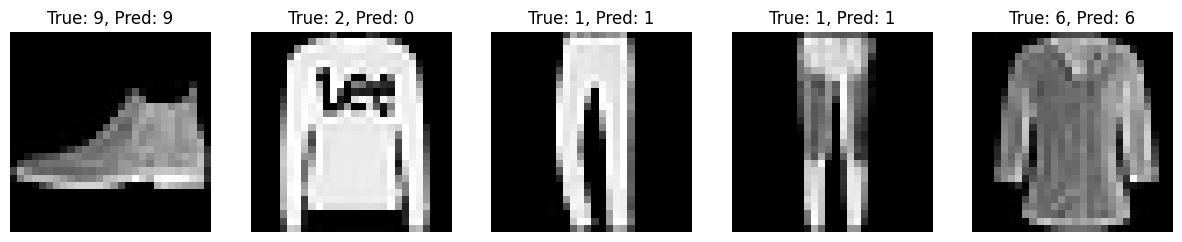

In [36]:
images, labels = next(iter(test_loader))
images = images.reshape(-1, 28*28).to(device)
labels = labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)
fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    ax[i].imshow(images[i].reshape(28, 28).cpu(), cmap='gray')
    ax[i].set_title(f'True: {labels[i].item()}, Pred: {predicted[i].item()}')
    ax[i].axis('off')
plt.show()